In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import os
import ast
import glob
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.signal import butter, filtfilt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

warnings.filterwarnings('ignore')
sns.set_theme(style='darkgrid')

In [ ]:
BASE_DIR       = '/content/drive/MyDrive/CSI_TRAINING'
CSI_DIR        = os.path.join(BASE_DIR, 'csi_data')
TIMESTAMP_DIR  = os.path.join(BASE_DIR, 'timestamps')

In [ ]:
def get_sample_csi(label = 'SMOKING'):
  csi_df = pd.read_csv(f'{CSI_DIR}/2026/4/25/2026-4-25_h3_1777087945-1777088520.csv')
  csi_ts = pd.read_csv(f'{TIMESTAMP_DIR}/20260425_113227.csv')

  smoking_stream = csi_ts[csi_ts['Behavior'] == label].head(2)[['Behavior', 'Behavior type', 'Time']]
  start_time, stop_time = smoking_stream['Time']

  csi_raw_packets = csi_df[(csi_df['timestamp_real'] >= start_time) & (csi_df['timestamp_real'] <= stop_time)].reset_index(drop=True)

  return csi_raw_packets

In [ ]:
def get_active_subcarriers():
  # Legacy Long Training Field (LLTF)
  LLTF_NULL = list(range(0, 6)) + [32] + list(range(59, 64)) # null subcarriers
  # LLTF_PILOTS = [7, 21, 43, 57] # pilot subcarriers

  # DISCARD_SUBCARRIERS = set(LLTF_NULL + LLTF_PILOTS)

  return [i for i in range(64) if i not in LLTF_NULL]

In [ ]:
def parse_csi_amplitude(raw_data_str, active_subcarriers):
    """
    Parse one row of the 'data' column and return the amplitude
    of the active subcarriers only.

    Parameters
    ----------
    raw_data_str : str  – e.g. '[0,0,0,22,0,20,...]'

    Returns
    -------
    amplitudes : np.ndarray, shape (len(active_subcarriers),)
    """
    flat = ast.literal_eval(raw_data_str)          # list of 384 ints
    iq   = np.array(flat, dtype=np.float32).reshape(-1, 2)  # (192, 2)
    imag = iq[:, 0]
    real = iq[:, 1]
    amplitude = np.sqrt(real**2 + imag**2)         # (192,)
    return amplitude[active_subcarriers]           # keep active only (52 subcarriers)

In [ ]:
sample_csi = get_sample_csi()
active_subcarriers = get_active_subcarriers()
sample_csi['amplitude'] = sample_csi['data'].apply(parse_csi_amplitude, args=(active_subcarriers,))

sample_csi['amplitude'].head()

,amplitude
0,"[6.708204, 5.8309517, 6.708204, 6.708204, 5.83..."
1,"[6.0827627, 6.0827627, 6.3245554, 6.0827627, 6..."
2,"[9.055386, 9.055386, 9.219544, 9.219544, 8.246..."
3,"[5.8309517, 6.4031243, 5.656854, 6.4031243, 5...."
4,"[6.708204, 6.708204, 6.708204, 6.708204, 6.708..."


## Subcarrier Picking for Visualization

Let's choose Subcarrier #7, #25, and #45 for visualization of CSI

In [ ]:
subcarrier_indices = [6, 14, 24,]

### Apply Hampel Filtering to Remove Outliers

I will define a `hampel_filter` function that identifies and replaces outliers in a time series (or in this case, a set of subcarriers for a single timestamp). The filter works by checking if each data point within a sliding window deviates from the window's median by more than `n_sigmas` (typically 3) times the Median Absolute Deviation (MAD). Outliers are replaced by the window's median.

In [ ]:
def hampel_filter(data, window_size=7, n_sigmas=3):
    """
    Applies the Hampel filter to a 1D numpy array.

    Parameters:
    data (np.ndarray): The input data (e.g., subcarrier amplitudes for one timestamp).
    window_size (int): The size of the sliding window (must be odd).
    n_sigmas (int): Number of standard deviations (or MADs) for outlier detection.

    Returns:
    np.ndarray: The filtered data.
    """
    n = len(data)
    if n < window_size:
        return np.copy(data) # Not enough data for filtering

    if window_size % 2 == 0:
        raise ValueError("window_size must be odd")
    k = (window_size - 1) // 2
    filtered_data = np.copy(data)

    # Iterate through the data, applying the filter within the sliding window
    for i in range(k, n - k):
        window = data[i - k : i + k + 1]
        median = np.median(window)
        # Calculate Median Absolute Deviation (MAD)
        mad = np.median(np.abs(window - median))
        # If MAD is zero, avoid division by zero and handle as no deviation
        if mad == 0:
            threshold = 0
        else:
            threshold = n_sigmas * mad

        if np.abs(data[i] - median) > threshold:
            filtered_data[i] = median
    return filtered_data


Now, I will apply this `hampel_filter` function to each row of the `amplitude` column in your `sample_csi` DataFrame, creating a new column named `filtered_amplitude`. After filtering, I will combine these individual arrays into a single NumPy matrix, where each row represents the filtered amplitudes for a given timestamp.

In [ ]:
# Apply the Hampel filter to each row of the 'amplitude' column
sample_csi['filtered_amplitude'] = sample_csi['amplitude'].apply(lambda x: hampel_filter(x))

# Combine the filtered amplitudes into a single matrix
csi_matrix = np.vstack(sample_csi['filtered_amplitude'].values)

print(f"Shape of the combined CSI matrix: {csi_matrix.shape}")
print("First 5 rows of the filtered amplitudes:")
display(sample_csi['filtered_amplitude'].head())

Shape of the combined CSI matrix: (484, 52)
First 5 rows of the filtered amplitudes:


,filtered_amplitude
0,"[6.708204, 5.8309517, 6.708204, 6.708204, 5.83..."
1,"[6.0827627, 6.0827627, 6.3245554, 6.3245554, 6..."
2,"[9.055386, 9.055386, 9.219544, 9.219544, 8.246..."
3,"[5.8309517, 6.4031243, 5.656854, 5.656854, 5.6..."
4,"[6.708204, 6.708204, 6.708204, 6.708204, 6.708..."


### Visualize Original CSI Stream with Hampel filtered CSI

Let's compare the original CSI data to CSI data that undergone Hampel Filtering.

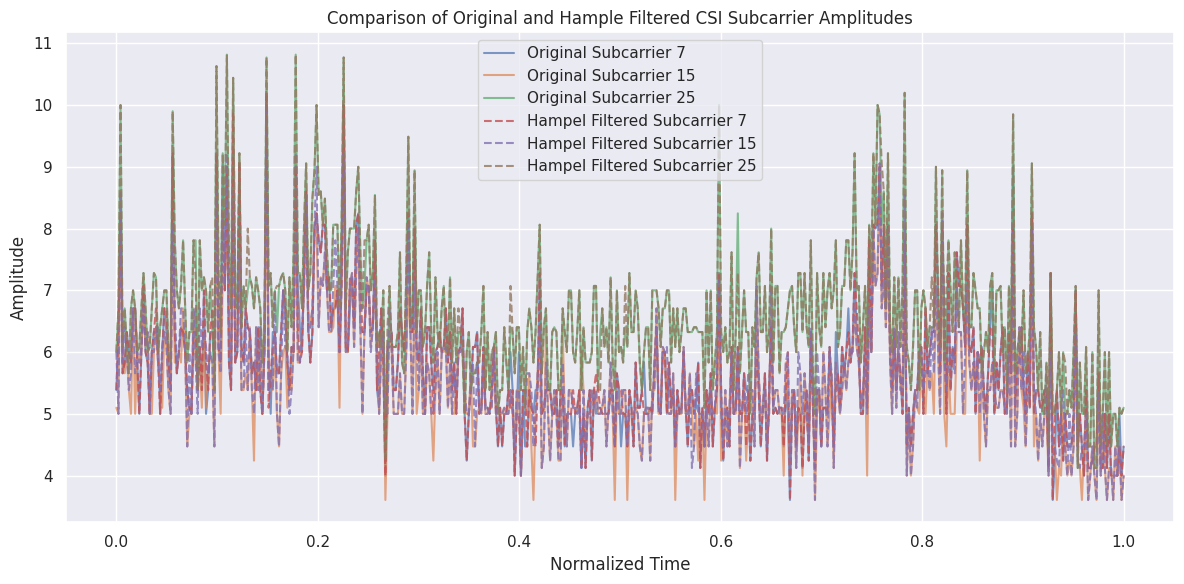

In [ ]:

original_csi = np.vstack(sample_csi['amplitude'].values)

plt.figure(figsize=(12, 6))

# Plot original data for chosen subcarriers
for i in subcarrier_indices:
    plt.plot(np.linspace(0, 1, original_csi.shape[0]), original_csi[:, i], label=f'Original Subcarrier {i+1}', alpha=0.7)

# Plot interpolated data for chosen subcarriers
for i in subcarrier_indices:
    plt.plot(np.linspace(0, 1, csi_matrix.shape[0]), csi_matrix[:, i], '--', label=f'Hampel Filtered Subcarrier {i+1}', alpha=0.8)

plt.title('Comparison of Original and Hample Filtered CSI Subcarrier Amplitudes')
plt.xlabel('Normalized Time')
plt.ylabel('Amplitude')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

### Apply Butterworth Low-Pass Filter

To further process the interpolated CSI data, I will apply a Butterworth low-pass filter. This filter is effective in removing high-frequency noise while preserving the lower-frequency components that typically represent human movements and gestures.

Here's how it works:
1.  **Filter Design**: I will use `scipy.signal.butter` to design the filter. This involves specifying the filter order, cutoff frequency, and the type of filter (low-pass).
2.  **Frequency Parameters**: Assuming a sampling frequency (`fs`) of 100 Hz (from the '100 mhz sampling' mentioned earlier for 3-second gesture activity) and a `cutoff_freq` of 5 Hz, which is a common value for gesture-related signals. The `nyquist` frequency is half the sampling frequency.
3.  **Filter Application**: I will use `scipy.signal.filtfilt` to apply the filter. `filtfilt` applies the filter forward and backward, ensuring zero-phase distortion.
4.  **Iterate and Filter**: The filter will be applied independently to each subcarrier (column) of the `interpolated_csi_matrix`.

In [ ]:
from scipy.signal import butter, filtfilt

def apply_butterworth_filter(data, cutoff_freq, fs, order=4):
    """
    Applies a Butterworth low-pass filter to the input data.

    Parameters:
    data (np.ndarray): The input 1D data array (e.g., a single subcarrier's time series).
    cutoff_freq (float): The cutoff frequency of the filter in Hz.
    fs (float): The sampling frequency of the data in Hz.
    order (int): The order of the Butterworth filter.

    Returns:
    np.ndarray: The filtered data.
    """
    nyquist = 0.5 * fs
    normal_cutoff = cutoff_freq / nyquist
    b, a = butter(order, normal_cutoff, btype='low', analog=False)
    filtered_data = filtfilt(b, a, data)
    return filtered_data

# Define filter parameters
fs = 100.0  # Sampling frequency (Hz)
cutoff_freq = 20  # Cutoff frequency (Hz)
filter_order = 4 # Order of the filter

# Initialize an empty array to store the filtered CSI data
filtered_csi_matrix = np.zeros_like(csi_matrix)

# Apply the Butterworth filter to each subcarrier
num_subcarriers = csi_matrix.shape[1]
for i in range(num_subcarriers):
    filtered_csi_matrix[:, i] = apply_butterworth_filter(csi_matrix[:, i], cutoff_freq, fs, filter_order)

print(f"Shape of the filtered CSI matrix: {filtered_csi_matrix.shape}")


Shape of the filtered CSI matrix: (484, 52)


Let's visualize a few subcarriers to observe the effect of the Butterworth low-pass filter compared to the interpolated data.

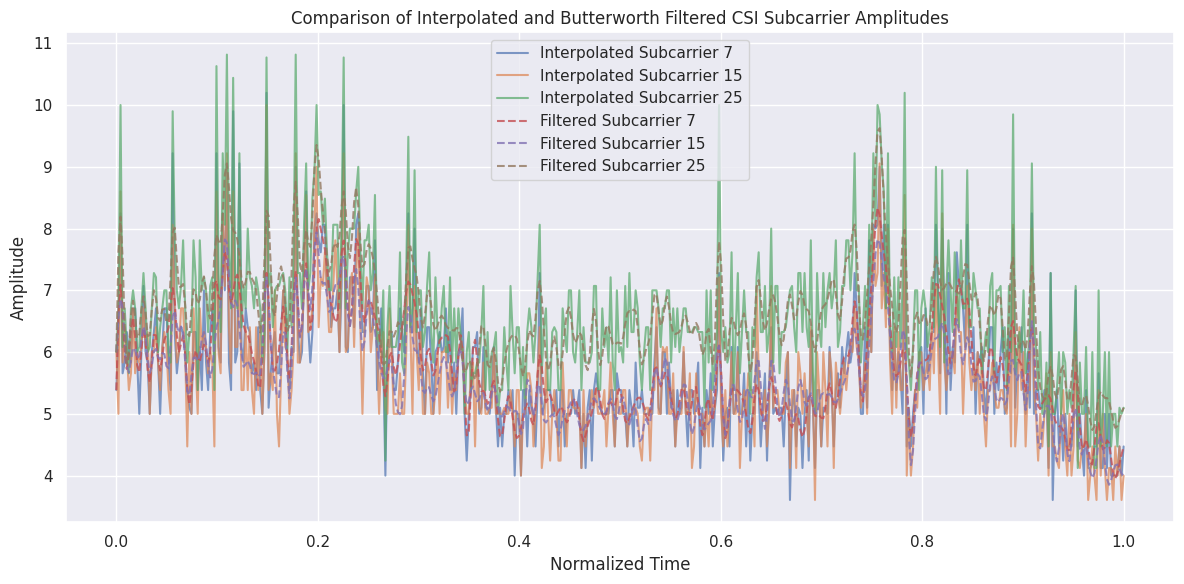

In [ ]:
plt.figure(figsize=(12, 6))

# Plot interpolated data for chosen subcarriers
for i in subcarrier_indices:
    plt.plot(np.linspace(0, 1, csi_matrix.shape[0]), csi_matrix[:, i], label=f'Interpolated Subcarrier {i+1}', alpha=0.7)

# Plot filtered data for the chosen subcarriers
for i in subcarrier_indices:
    plt.plot(np.linspace(0, 1, filtered_csi_matrix.shape[0]), filtered_csi_matrix[:, i], '--', label=f'Filtered Subcarrier {i+1}', alpha=0.8)

plt.title('Comparison of Interpolated and Butterworth Filtered CSI Subcarrier Amplitudes')
plt.xlabel('Normalized Time')
plt.ylabel('Amplitude')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

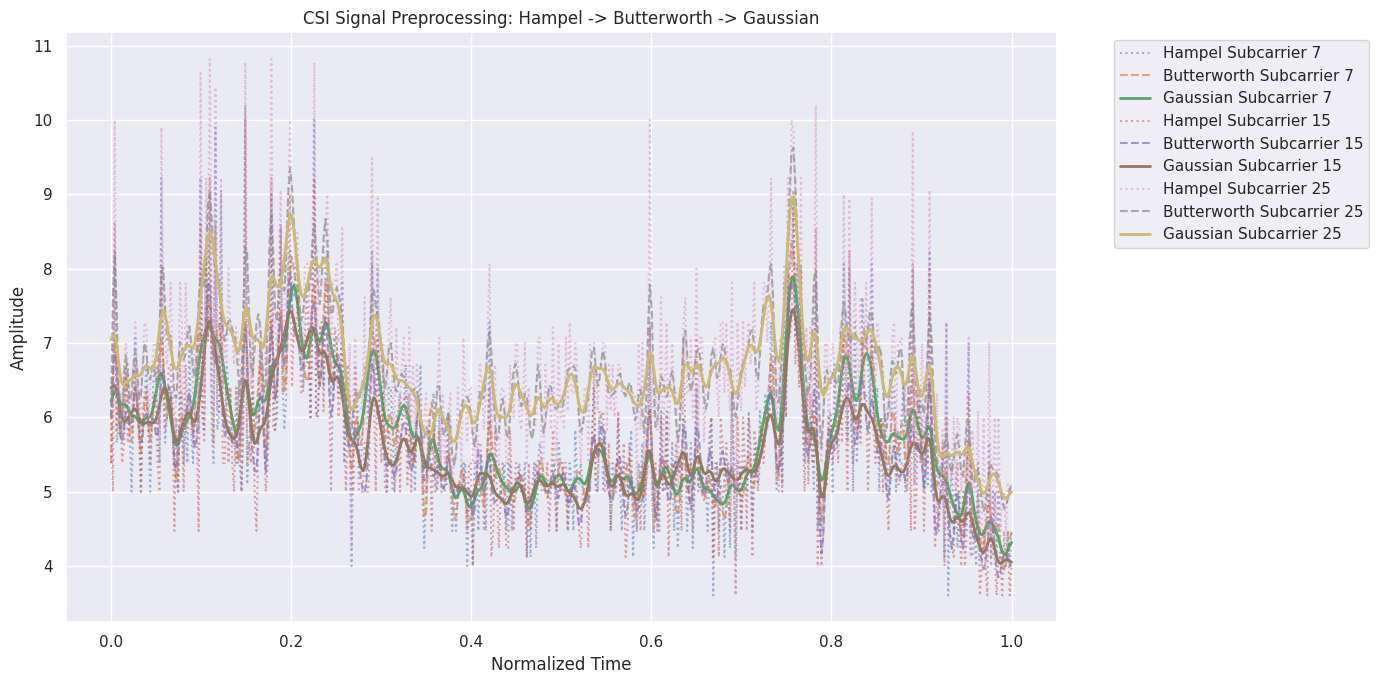

In [ ]:
from scipy.ndimage import gaussian_filter1d

# Define Gaussian sigma
sigma = 2

# Initialize an empty array to store the Gaussian-smoothed CSI data
gaussian_csi_matrix = np.zeros_like(filtered_csi_matrix)

# Apply Gaussian smoothing to each subcarrier
for i in range(num_subcarriers):
    gaussian_csi_matrix[:, i] = gaussian_filter1d(filtered_csi_matrix[:, i], sigma=sigma)

# Visualization
plt.figure(figsize=(14, 7))

# Define a subset of subcarriers to visualize
for i in subcarrier_indices:
    time_axis = np.linspace(0, 1, filtered_csi_matrix.shape[0])
    plt.plot(time_axis, csi_matrix[:, i], ':', label=f'Hampel Subcarrier {i+1}', alpha=0.5)
    plt.plot(time_axis, filtered_csi_matrix[:, i], '--', label=f'Butterworth Subcarrier {i+1}', alpha=0.7)
    plt.plot(time_axis, gaussian_csi_matrix[:, i], '-', label=f'Gaussian Subcarrier {i+1}', linewidth=2)

plt.title('CSI Signal Preprocessing: Hampel -> Butterworth -> Gaussian')
plt.xlabel('Normalized Time')
plt.ylabel('Amplitude')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True)
plt.tight_layout()
plt.show()

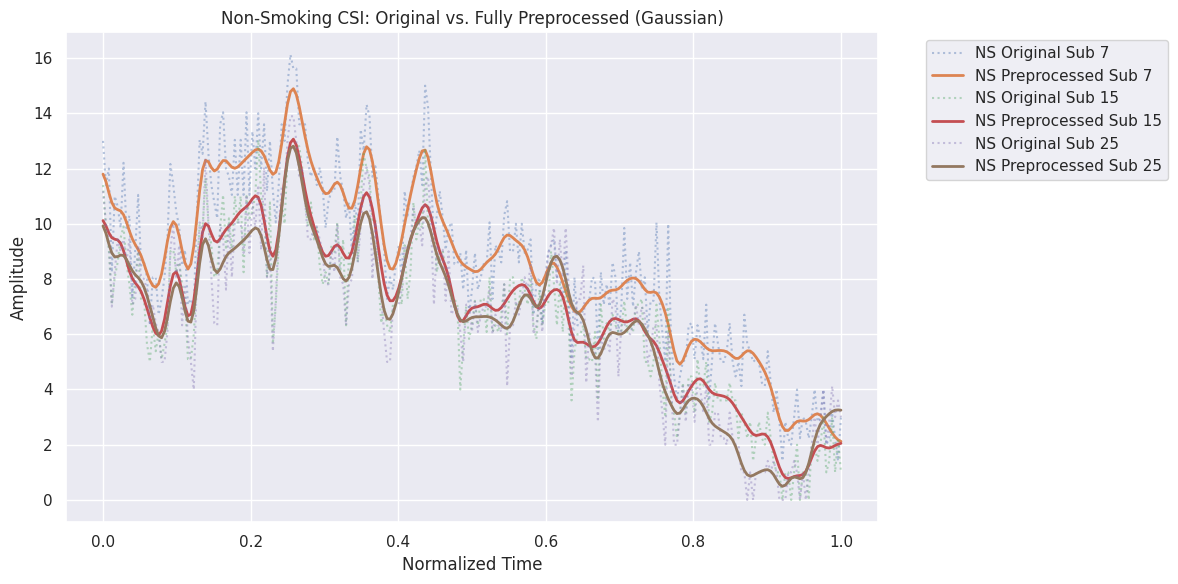

In [ ]:
# Pipeline for visualizing CSI

# 1. Hampel Filter
non_smoking_sample['filtered_amplitude'] = non_smoking_sample['amplitude'].apply(lambda x: hampel_filter(x))
ns_csi_matrix = np.vstack(non_smoking_sample['filtered_amplitude'].values)

# 2. Butterworth Filter
ns_filtered_matrix = np.zeros_like(ns_csi_matrix)
for i in range(ns_csi_matrix.shape[1]):
    ns_filtered_matrix[:, i] = apply_butterworth_filter(ns_csi_matrix[:, i], cutoff_freq=20, fs=100.0)

# 3. Gaussian Smoothing
ns_gaussian_matrix = np.zeros_like(ns_filtered_matrix)
for i in range(ns_filtered_matrix.shape[1]):
    ns_gaussian_matrix[:, i] = gaussian_filter1d(ns_filtered_matrix[:, i], sigma=2)

# Visualization
plt.figure(figsize=(12, 6))
time_axis_ns = np.linspace(0, 1, ns_gaussian_matrix.shape[0])

for i in subcarrier_indices:
    plt.plot(time_axis_ns, ns_original_csi[:, i], ':', label=f'NS Original Sub {i+1}', alpha=0.4)
    plt.plot(time_axis_ns, ns_gaussian_matrix[:, i], '-', label=f'NS Preprocessed Sub {i+1}', linewidth=2)

plt.title('Non-Smoking CSI: Original vs. Fully Preprocessed (Gaussian)')
plt.xlabel('Normalized Time')
plt.ylabel('Amplitude')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
from scipy.ndimage import gaussian_filter1d
from scipy.interpolate import interp1d

def preprocess_csi_data(df, active_subcarriers, target_packets, fs=100.0, cutoff_freq=5.0, sigma=2):
    """
    Applies adjusted preprocessing: parsing, Hampel filter, Butterworth filter,
    Gaussian smoothing, and finally interpolation.
    """
    # 1. Parse Amplitude
    df['amplitude'] = df['data'].apply(parse_csi_amplitude, args=(active_subcarriers,))

    # 2. Hampel Filter
    df['filtered_amplitude'] = df['amplitude'].apply(lambda x: hampel_filter(x))
    csi_matrix = np.vstack(df['filtered_amplitude'].values)
    current_packets, num_subcarriers = csi_matrix.shape

    # 3. Butterworth Low-Pass Filter
    bw_filtered_matrix = np.zeros_like(csi_matrix)
    for i in range(num_subcarriers):
        bw_filtered_matrix[:, i] = apply_butterworth_filter(csi_matrix[:, i], cutoff_freq, fs)

    # 4. Gaussian Smoothing
    gauss_filtered_matrix = np.zeros_like(bw_filtered_matrix)
    for i in range(num_subcarriers):
        gauss_filtered_matrix[:, i] = gaussian_filter1d(bw_filtered_matrix[:, i], sigma=sigma)

    # 5. Interpolation (Only after preprocessing)
    original_time = np.linspace(0, 1, current_packets)
    new_time = np.linspace(0, 1, target_packets)
    interpolated_matrix = np.zeros((target_packets, num_subcarriers))

    for i in range(num_subcarriers):
        interp_func = interp1d(original_time, gauss_filtered_matrix[:, i], kind='linear')
        interpolated_matrix[:, i] = interp_func(new_time)

    return interpolated_matrix

In [ ]:
from IPython.display import clear_output

def calculate_target_packets(timestamp_dir, fs=100.0):
    ts_files = glob.glob(os.path.join(timestamp_dir, '*.csv'))
    durations = []
    for ts_path in ts_files:
        ts_df = pd.read_csv(ts_path)
        for i in range(0, len(ts_df) - 1, 2):
            if ts_df.iloc[i]['Behavior'] != 'SMOKING': continue
            if ts_df.iloc[i]['Behavior type'] == 'START' and ts_df.iloc[i+1]['Behavior type'] == 'STOP':
                durations.append(ts_df.iloc[i+1]['Time'] - ts_df.iloc[i]['Time'])
    avg_duration = np.mean(durations)
    int_avg_duration = int(avg_duration * fs)
    return round(int_avg_duration, -1)

def preprocess_all_data(csi_dir, timestamp_dir, active_subcarriers):
    # Calculate target packets from training timestamps
    target_packets = calculate_target_packets(timestamp_dir)
    print(f"Calculated target packets (sliding window): {target_packets}")

    all_features = []
    all_labels = []
    ts_files = glob.glob(os.path.join(timestamp_dir, '*.csv'))
    csi_files = glob.glob(os.path.join(csi_dir, '**/*.csv'), recursive=True)

    counter = 0
    counter_path = 0

    for ts_path in ts_files:
        counter = 0
        counter_path = counter_path + 1
        ts_df = pd.read_csv(ts_path)
        for i in range(0, len(ts_df) - 1, 2):
            counter = counter + 1

            clear_output(wait=True)
            print(f"Calculated target packets (sliding window): {target_packets}")
            print(f"#{counter_path}/{int(len(ts_files))} preprocessing {counter}/{int(len(ts_df) / 2)}...")

            row_start, row_stop = ts_df.iloc[i], ts_df.iloc[i+1]
            if row_start['Behavior type'] != 'START' or row_stop['Behavior type'] != 'STOP': continue

            behavior = row_start['Behavior']

            if behavior not in ['SMOKING', 'NON-SMOKING']: continue

            start_time, stop_time = row_start['Time'], row_stop['Time']
            label = 1 if behavior == 'SMOKING' else 0

            matching_csi_file = None
            for f in csi_files:
                try:
                    time_part = os.path.basename(f).split('_')[-1].replace('.csv', '')
                    f_start, f_stop = map(int, time_part.split('-'))
                    if start_time >= f_start and stop_time <= f_stop:
                        matching_csi_file = f
                        break
                except: continue

            if matching_csi_file:
                csi_df = pd.read_csv(matching_csi_file)
                segment_df = csi_df[(csi_df['timestamp_real'] >= start_time) & (csi_df['timestamp_real'] <= stop_time)].reset_index(drop=True)
                if len(segment_df) > 10:
                    try:
                        features = preprocess_csi_data(segment_df, active_subcarriers, target_packets=target_packets)
                        all_features.append(features)
                        all_labels.append(label)
                    except Exception as e: print(f"Error: {e}")

    return np.array(all_features), np.array(all_labels)

# Run the bulk preprocessing with new logic
X, y = preprocess_all_data(CSI_DIR, TIMESTAMP_DIR, active_subcarriers)
print(f"Bulk preprocessing complete. Features shape: {X.shape}")

Calculated target packets (sliding window): 720
#13/13 preprocessing 60/60...
Bulk preprocessing complete. Features shape: (585, 720, 52)


### ResNet Feature Extraction for LSTM

To feed the CSI data into an LSTM through a ResNet architecture, we must:
1. **Reshape the data**: Add a channel dimension so it looks like $(Samples, Time, Subcarriers, 1)$.
2. **Feature Extraction**: Use a ResNet-like CNN structure to process each time segment.
3. **Time Distributed**: Wrap the CNN in a `TimeDistributed` layer so the LSTM can process the sequence of extracted features.

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models
import numpy as np

# 1. Prepare data for CNN (Add channel dimension)
X_resnet = np.expand_dims(X, axis=-1)
print(f"New shape for ResNet input: {X_resnet.shape}")

def build_resnet_extractor(input_shape):
    """Defines a simple ResNet block for feature extraction using Conv1D"""
    input_layer = layers.Input(shape=input_shape)

    # First Conv Block (1D since our features are subcarriers)
    x = layers.Conv1D(32, 3, padding='same', activation='relu')(input_layer)
    shortcut = x

    # Residual Block
    x = layers.Conv1D(32, 3, padding='same', activation='relu')(x)
    x = layers.Conv1D(32, 3, padding='same')(x)
    x = layers.Add()([x, shortcut])
    x = layers.Activation('relu')(x)
    x = layers.MaxPooling1D(2)(x)

    # Flatten to feed into LSTM
    x = layers.Flatten()(x)
    return models.Model(inputs=input_layer, outputs=x)

print("ResNet Extractor updated to Conv1D.")

New shape for ResNet input: (585, 720, 52, 1)
ResNet Extractor updated to Conv1D.


### Build Hybrid ResNet-LSTM Model

We will now combine the ResNet extractor with an LSTM.
- **TimeDistributed**: This layer allows us to apply the ResNet convolution to each 'frame' (time step) of the CSI sequence.
- **LSTM**: This layer learns the temporal dependencies across the 500 time steps.
- **Dense**: A final sigmoid layer for binary classification (Smoking vs. Non-Smoking).

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import TimeDistributed, LSTM, Dense, Dropout

def build_combined_model(input_shape_with_time):
    # input_shape_with_time: (target_packets, 52, 1)
    frame_shape = input_shape_with_time[1:] # (52, 1)

    # 1. Instantiate the ResNet Extractor
    resnet_extractor = build_resnet_extractor(frame_shape)

    # 2. Build Sequential Model
    model = Sequential([
        # Apply ResNet to every time step
        TimeDistributed(resnet_extractor, input_shape=input_shape_with_time),

        # Temporal processing
        LSTM(64, return_sequences=False),
        Dropout(0.5),

        # Classification head
        Dense(32, activation='relu'),
        Dense(1, activation='sigmoid')
    ])

    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    return model

# Instantiate and summary
model_input_shape = (calculate_target_packets(TIMESTAMP_DIR), 52, 1)
final_model = build_combined_model(model_input_shape)
final_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ time_distributed                │ (None, 720, 832)       │         6,336 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 64)             │       229,632 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 238,081 (930.00 KB)

 Trainable params: 238,081 (930.00 KB)

 Non-trainable params: 0 (0.00 B)

### Model Training

I will split the preprocessed data into training (80%) and validation (20%) sets, then train the model for 20 epochs with a batch size of 32.

Epoch 1/30
15/15 ━━━━━━━━━━━━━━━━━━━━ 14s 854ms/step - accuracy: 0.6966 - loss: 0.5844 - val_accuracy: 0.7009 - val_loss: 0.6172
Epoch 2/30
15/15 ━━━━━━━━━━━━━━━━━━━━ 8s 482ms/step - accuracy: 0.6902 - loss: 0.5790 - val_accuracy: 0.7094 - val_loss: 0.6035
Epoch 3/30
15/15 ━━━━━━━━━━━━━━━━━━━━ 6s 434ms/step - accuracy: 0.6966 - loss: 0.5817 - val_accuracy: 0.7094 - val_loss: 0.6000
Epoch 4/30
15/15 ━━━━━━━━━━━━━━━━━━━━ 7s 476ms/step - accuracy: 0.7158 - loss: 0.5735 - val_accuracy: 0.6752 - val_loss: 0.6129
Epoch 5/30
15/15 ━━━━━━━━━━━━━━━━━━━━ 7s 464ms/step - accuracy: 0.6880 - loss: 0.5796 - val_accuracy: 0.6923 - val_loss: 0.5949
Epoch 6/30
15/15 ━━━━━━━━━━━━━━━━━━━━ 7s 452ms/step - accuracy: 0.7179 - loss: 0.5606 - val_accuracy: 0.7009 - val_loss: 0.5952
Epoch 7/30
15/15 ━━━━━━━━━━━━━━━━━━━━ 7s 478ms/step - accuracy: 0.7308 - loss: 0.5459 - val_accuracy: 0.7009 - val_loss: 0.5800
Epoch 8/30
15/15 ━━━━━━━━━━━━━━━━━━━━ 7s 442ms/step - accuracy: 0.7158 - loss: 0.5527 - val_accuracy: 0

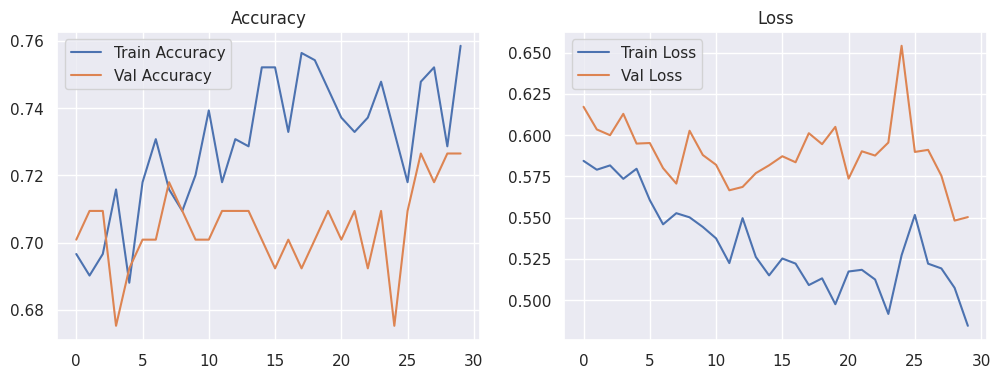

In [ ]:
from sklearn.model_selection import train_test_split

# Split data into training and validation sets
X_train, X_val, y_train, y_val = train_test_split(
    X_resnet, y, test_size=0.2, random_state=42, stratify=y
)

# Train the model
history = final_model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=30,
    batch_size=32,
    verbose=1
)

# Visualize training history
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Loss')
plt.legend()

plt.show()

### Model Evaluation on Test Data

I will now:
1. Define the test data paths.
2. Preprocess the test datasets.
3. Evaluate the model performance using Accuracy, F1-score, and a Confusion Matrix.

In [ ]:
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report

X_test_raw = X_val
y_test = y_val

# 3. Reshape for ResNet-LSTM input
X_test = np.expand_dims(X_test_raw, axis=-1)

# 4. Generate predictions
y_pred_prob = final_model.predict(X_test)
y_pred = (y_pred_prob > 0.5).astype(int)

# 5. Calculate Metrics
acc = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
print(f"Test Accuracy: {acc:.4f}")
print(f"Test F1-Score: {f1:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 294ms/step
Test Accuracy: 0.7265
Test F1-Score: 0.7714

Classification Report:
              precision    recall  f1-score   support

           0       0.86      0.53      0.66        58
           1       0.67      0.92      0.77        59

    accuracy                           0.73       117
   macro avg       0.76      0.72      0.72       117
weighted avg       0.76      0.73      0.72       117



### Plot Confusion Matrix

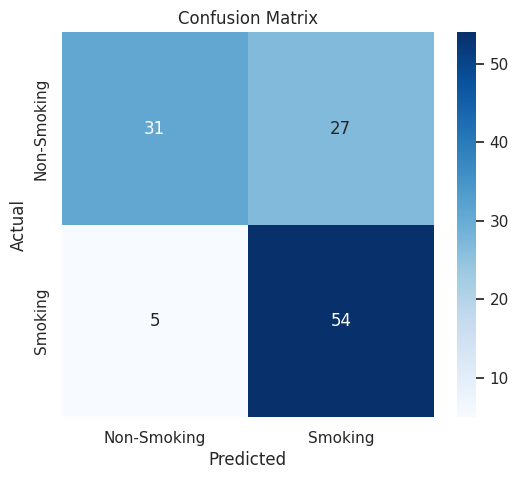

In [ ]:
# 6. Plot Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Non-Smoking', 'Smoking'],
            yticklabels=['Non-Smoking', 'Smoking'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()